# Helpers

In [6]:
import seaborn as sns
from pymatreader import read_mat
import os
import pandas as pd
import numpy as np
from nilearn import plotting
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import networkx as nx
from scipy.linalg import expm, eigvals
from concurrent.futures import ProcessPoolExecutor, as_completed

from concurrent.futures import ThreadPoolExecutor, as_completed


def _onnela_clustering_global(W):
    """Onnela et al. 2005 — consistente con _process_subject."""
    w_max = W.max()
    if w_max == 0: return 0.0
    W_cbrt = np.cbrt(W / w_max)
    k      = (W > 0).sum(axis=1).astype(float)
    num    = np.sum((W_cbrt @ W_cbrt) * W_cbrt, axis=1)
    denom  = k * (k - 1)
    with np.errstate(invalid='ignore', divide='ignore'):
        c_i = np.where(denom > 0, num / denom, 0.0)
    return c_i.mean()


def _metrics_one_thread(args):
    idx, A, rho = args
    A = A.copy(); np.fill_diagonal(A, 0)
    N = A.shape[0]

    # Unweighted — networkx OK
    G_unw = nx.from_numpy_array((A > 0).astype(float))
    c_unw = nx.average_clustering(G_unw)

    # Weighted — Onnela, igual que _process_subject
    c_w = _onnela_clustering_global(A)

    # Communicabilidad global
    sr = np.abs(eigvals(A)).max()
    A_norm = A * (rho / sr) if sr > 0 else A
    try:
        C    = expm(A_norm)
        comm = (C.sum() - np.trace(C)) / (N * (N - 1))
        sc   = np.diag(C).mean()
    except Exception:
        comm = np.nan
        sc   = np.full(N, np.nan)

    return idx, c_unw, c_w, comm, sc

def compute_extra_metrics(df, rho=0.99, n_workers=8):
    df = df.copy()
    c_unw_out = [None] * len(df)
    c_w_out   = [None] * len(df)
    comm_out  = [None] * len(df)
    sc_out    = [None] * len(df)

    args_list = [
        (idx, np.asarray(row.connectome, dtype=np.float64), rho)
        for idx, (_, row) in enumerate(df.iterrows())
    ]

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_metrics_one_thread, a): a[0] for a in args_list}
        for fut in as_completed(futures):
            idx, c_unw, c_w, comm, sc = fut.result()
            c_unw_out[idx] = c_unw
            c_w_out[idx]   = c_w
            comm_out[idx]  = comm
            sc_out[idx]    = sc

    df['C_unw']     = c_unw_out
    df['C_w']       = c_w_out
    df['comm_mean'] = comm_out
    df['sc_mean']   = sc_out
    return df


def ddw_group_rep(connectomes, dist_mat, hemi, n_bins=22, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    N_subs  = len(connectomes)
    N_nodes = connectomes[0].shape[0]

    # 1. Frecuencia, peso medio y pool de pesos
    freq         = np.zeros((N_nodes, N_nodes))
    avg_w        = np.zeros((N_nodes, N_nodes))
    weights_pool = {(i, j): [] for i in range(N_nodes) for j in range(i+1, N_nodes)}

    for adj in connectomes:
        A = np.triu(adj, 1)
        freq += (A > 0).astype(int)
        avg_w += A
        rows, cols = A.nonzero()
        for r, c in zip(rows, cols):
            weights_pool[(r, c)].append(A[r, c])

    avg_w = np.divide(avg_w, freq, out=np.zeros_like(avg_w), where=freq != 0)
    group_rep = np.zeros((N_nodes, N_nodes))

    # 2. Máscara 2D intra/inter correcta
    hemi_i, hemi_j = np.meshgrid(hemi, hemi, indexing='ij')  # (N, N)

    for is_intra in [True, False]:
        mask_hemi_2d = (hemi_i == hemi_j) if is_intra else (hemi_i != hemi_j)
        mask_valid   = np.triu(mask_hemi_2d, 1) & (freq > 0)

        if not np.any(mask_valid):
            continue

        valid_edges  = np.argwhere(mask_valid)
        distances    = dist_mat[valid_edges[:, 0], valid_edges[:, 1]]

        bins          = np.percentile(distances, np.linspace(0, 100, n_bins + 1))
        bins[-1]     += 1e-5
        edge_bin_idx  = np.digitize(distances, bins) - 1

        # 3. Consenso topológico por bin
        for b in range(n_bins):
            idx_in_bin = np.where(edge_bin_idx == b)[0]
            if len(idx_in_bin) == 0:
                continue

            bin_pairs = valid_edges[idx_in_bin]
            pi, pj    = bin_pairs[:, 0], bin_pairs[:, 1]

            # n_keep = media de conexiones por sujeto en este bin (fiel al paper)
            counts_per_subj = np.array([np.sum(adj[pi, pj] > 0) for adj in connectomes])
            n_keep = int(np.round(counts_per_subj.mean()))
            n_keep = min(n_keep, len(idx_in_bin))
            if n_keep == 0:
                continue

            # Ordenar por consenso desc, desempate por peso medio desc
            edge_stats = [(freq[u, v], avg_w[u, v], u, v) for u, v in bin_pairs]
            edge_stats.sort(key=lambda x: (x[0], x[1]), reverse=True)

            # 4. Asignar pesos por muestreo
            for _, _, u, v in edge_stats[:n_keep]:
                pool = weights_pool.get((u, v), [])
                if pool:
                    group_rep[u, v] = rng.choice(pool)
                    group_rep[v, u] = group_rep[u, v]

    return group_rep
 
def null_model_kY(ks=None):
    """
    Devuelve arrays de referencia para el scatter kY(k):
      kY_null (media), kY_null_hi (media+2σ), kY_null_lo (=1),
      kY_hom (totalmente homogéneo), kY_het (totalmente heterogéneo)
    """
    if ks is None:
        ks = np.arange(2, 90)
    kY_null = 2 * ks / (ks + 1)
    term1   = (20 + 4*ks) / ((ks+1) * (ks+2) * (ks+3))
    term2   = 4 / (ks+1)**2
    var_kY  = (ks**2) * (term1 - term2)
    return dict(
        ks      = ks,
        kY_null = kY_null,
        kY_hi   = kY_null + 2*np.sqrt(var_kY),
        kY_lo   = np.ones_like(ks, dtype=float),
        kY_hom  = np.ones_like(ks, dtype=float),
        kY_het  = ks.astype(float),
    )
 

def make_ds_colors(ds_list):
    """Devuelve dict {dataset_id: color} con tab10."""
    cmap = plt.cm.tab10
    return {ds: cmap(i / max(len(ds_list) - 1, 1)) for i, ds in enumerate(ds_list)}
 
 
# ── Métricas de red ──────────────────────────────────────────────────────────
 
def node_metrics(adj):
    """
    Métricas por nodo para una matriz de adyacencia pesada.
    Devuelve: k (degree), s (strength), Y (disparity), kY (k·Y)
    """
    A = adj.copy(); np.fill_diagonal(A, 0)
    k  = (A > 0).sum(axis=1).astype(float)
    s  = A.sum(axis=1)
    p  = A / np.where(s > 0, s, 1.)[:, None]
    Yi = (p**2).sum(axis=1)
    #average weight of a node
    wi = np.divide(s, k, out=np.zeros_like(s, dtype=float), where=k>0)
    
    
    return k, s, Yi, k * Yi, wi
 
 
def subject_metrics(conn_array, N_roi=90):
    """
    Métricas escalares por sujeto para un array de conectomas.
    Devuelve DataFrame con: density, strength, degree, Y_obs, kY_obs, Y_null, Ratio
    """
    n = len(conn_array)
    D, S, K, Y, kY, YN, R = [np.zeros(n) for _ in range(7)]
    for i, raw in enumerate(conn_array):
        adj = raw.copy(); np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        v = k > 1
        if v.sum() == 0:
            D[i] = S[i] = K[i] = Y[i] = kY[i] = YN[i] = R[i] = np.nan
            continue
        D[i]  = (adj > 0).sum() / (N_roi * (N_roi - 1))
        S[i]  = s[v].mean()
        K[i]  = k[v].mean()
        Y[i]  = Yi[v].mean()
        kY[i] = kYi[v].mean()
        YN[i] = (2. / (k[v] + 1)).mean()
        R[i]  = (Yi[v] / (2. / (k[v] + 1))).mean()
    return pd.DataFrame(dict(density=D, strength=S, degree=K,
                             Y_obs=Y, kY_obs=kY, Y_null=YN, Ratio=R, ))
 
 
def subj_stats(adj):
    """Stats de red (min/max/mu/var de k, w, s) para un conectoma. Devuelve dict."""
    A = adj.copy(); np.fill_diagonal(A, 0)
    k = (A > 0).sum(axis=1).astype(float)
    s = A.sum(axis=1); w = A[A > 0]; v = k > 0
    if v.sum() == 0 or len(w) == 0:
        return {}
    return {'N': int(v.sum()),
            'k_min': k[v].min(), 'k_max': k[v].max(),
            'k_mu': k[v].mean(), 'k_var': k[v].var(),
            'w_min': w.min(),    'w_max': w.max(),
            'w_mu':  w.mean(),   'w_var': w.var(),
            's_min': s[v].min(), 's_max': s[v].max(),
            's_mu':  s[v].mean(),'s_var': s[v].var()}
 
 
def by_degree(conn_list):
    """
    Para cada clase de degree k, calcula media de Y, kY y Ratio
    sobre todos los conectomas de conn_list.
    Devuelve dict {k: (Y_mean, Ratio_mean, kY_mean, n_connectomes)}
    """
    acc = defaultdict(lambda: {'Y': [], 'R': [], 'kY': [], 'nc': 0})
    for adj in conn_list:
        k, s, Yi, kYi, wi = node_metrics(adj)
        seen = set()
        for ki in np.unique(k[k > 1].astype(int)):
            m = k == ki
            acc[ki]['Y'].append(Yi[m].mean())
            acc[ki]['kY'].append(kYi[m].mean())   # ← fix: era kYi[i]
            acc[ki]['R'].append((Yi[m] / (2. / (ki + 1))).mean())
            seen.add(ki)
        for ki in seen:
            acc[ki]['nc'] += 1
    return {ki: (np.mean(v['Y']), np.mean(v['R']), np.mean(v['kY']), v['nc'])
            for ki, v in acc.items()}
    
    
def _logbins_hist(vals, n_bins=25):
    """Histograma en escala log con centros geométricos. Devuelve (centros, densidad)."""
    vals = vals[vals > 0]
    if len(vals) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(vals.min() + 1e-15),
                       np.log10(vals.max() + 1e-15), n_bins + 1)
    h, e = np.histogram(vals, bins=bins, density=True)
    c = np.sqrt(e[:-1] * e[1:])
    return c[h > 0], h[h > 0]
 

def plot_distributions(subjects, ax_pw, ax_ps, ax_cpk, ax_sk,
                       color='steelblue', alpha=0.5, ms=2, lw=0.8,
                       ks_ref=None, show_Y0=True):
    """
    Acumula distribuciones normalizadas y dibuja mediana ± IQR (banda).
    Normalización: w/w_max, s/s_max por sujeto. x de CCDF y s(k): k/k_max.
    """
    pw_acc  = defaultdict(list)   # bin_center → list of densities
    ps_acc  = defaultdict(list)
    pk_acc  = defaultdict(list)
    sk_acc  = defaultdict(list)

    W_BINS = np.logspace(-4, 0, 26)   # normalized bins [0,1]
    S_BINS = np.logspace(-4, 0, 26)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        w = adj[adj > 0]; v = k > 1
        if v.sum() == 0:
            continue

        wmax = w.max() if w.max() > 0 else 1
        smax = s[v].max() if s[v].max() > 0 else 1
        kmax = k[v].max() if k[v].max() > 0 else 1

        # P(w) normalized
        wn = w / wmax
        h, e = np.histogram(wn[wn > 0], bins=W_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            pw_acc[ci].append(hi)

        # P(s) normalized
        sn = s[v] / smax
        h, e = np.histogram(sn[sn > 0], bins=S_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            ps_acc[ci].append(hi)

        # CCDF and s(k) — k normalized by k_max
        ku, kc = np.unique(k[v].astype(int), return_counts=True)
        pk = kc / kc.sum()
        for ki, pi in zip(ku, pk):
            pk_acc[ki / kmax].append(pi)
            sk_acc[ki / kmax].append(s[k == ki].mean() / smax)

    def _plot_band(ax, acc_dict, color, alpha, lw):
        if not acc_dict:
            return
        xs = np.array(sorted(acc_dict))
        med = np.array([np.median(acc_dict[x]) for x in xs])
        q25 = np.array([np.percentile(acc_dict[x], 25) for x in xs])
        q75 = np.array([np.percentile(acc_dict[x], 75) for x in xs])
        ax.loglog(xs, med, '-', lw=lw + 0.2, alpha=min(alpha + 0.3, 1), color=color)
        ax.fill_between(xs, q25, q75, alpha=alpha * 0.4, color=color, linewidth=0)

    # CCDF needs cumulative from sorted k/k_max
    if pk_acc:
        ks = np.array(sorted(pk_acc))
        pk_med = np.array([np.median(pk_acc[x]) for x in ks])
        pk_q25 = np.array([np.percentile(pk_acc[x], 25) for x in ks])
        pk_q75 = np.array([np.percentile(pk_acc[x], 75) for x in ks])
        ccdf_med = np.cumsum(pk_med[::-1])[::-1]
        ccdf_q25 = np.cumsum(pk_q25[::-1])[::-1]
        ccdf_q75 = np.cumsum(pk_q75[::-1])[::-1]
        ccdf_med = ccdf_med / ccdf_med.max()   # fuerza a empezar en 1
        ccdf_q25 = ccdf_q25 / ccdf_q25.max()
        ccdf_q75 = ccdf_q75 / ccdf_q75.max()

        ax_cpk.loglog(ks, ccdf_med, '-', lw=lw + 0.2,
                      alpha=min(alpha + 0.3, 1), color=color)
        ax_cpk.fill_between(ks, ccdf_q25, ccdf_q75,
                            alpha=alpha * 0.4, color=color, linewidth=0)

    _plot_band(ax_pw, pw_acc, color, alpha, lw)
    _plot_band(ax_ps, ps_acc, color, alpha, lw)
    _plot_band(ax_sk, sk_acc, color, alpha, lw)

    ax_pw.set_xlabel('$w/w_{max}$');     ax_pw.set_ylabel('$P(w)$')
    ax_ps.set_xlabel('$s/s_{max}$');     ax_ps.set_ylabel('$P(s)$')
    ax_cpk.set_xlabel('$k/k_{max}$');    ax_cpk.set_ylabel('$P(K\\geq k)$')
    ax_sk.set_xlabel('$k/k_{max}$');     ax_sk.set_ylabel('$\\langle s/s_{max}\\rangle_k$')


def ddw_group_rep(connectomes, dist_mat, hemi, n_bins=22, rng=None):
    """
    DDW group-representative connectome.

    Topología: traducción fiel del código oficial de Betzel (fcn_group_bins.m),
    vía la implementación Python de Levakov (GidLev/consensus-thresholding).
    Pesos: muestreo aleatorio DDW según Mišić et al. (2015).

    Parameters
    ----------
    connectomes : list of np.ndarray (N, N)
    dist_mat    : np.ndarray (N, N)  — distancias entre ROIs
    hemi        : np.ndarray (N,)    — hemisferio por nodo (0=izq, 1=der)
    n_bins      : int                — número de bins de distancia (default 22)
    rng         : np.random.Generator | None

    Returns
    -------
    group_rep : np.ndarray (N, N)  — simétrico, ponderado
    """
    if rng is None:
        rng = np.random.default_rng(42)

    connectomes = [np.asarray(c, dtype=float) for c in connectomes]
    N     = connectomes[0].shape[0]
    nsub  = len(connectomes)

    # Stack en 3D: (N, N, nsub)
    adj = np.stack(connectomes, axis=2)

    # Consistencia y peso medio (exactamente como Betzel)
    C = np.sum(adj > 0, axis=2)           # nº sujetos con esa arista
    with np.errstate(invalid='ignore'):
        W = np.sum(adj, axis=2) / C       # peso medio entre quienes la tienen
    W[np.isnan(W)] = 0

    # Pool de pesos para muestreo DDW
    iu_r, iu_c = np.triu_indices(N, k=1)
    weights_pool = {}
    for r, c in zip(iu_r, iu_c):
        ws = adj[r, c, :]
        ws = ws[ws > 0]
        if len(ws) > 0:
            weights_pool[(r, c)] = ws

    # Bins de distancia lineales sobre distancias no-cero
    # (igual que Betzel: np.linspace sobre [min_nonzero, max])
    nonzero_dists = dist_mat[dist_mat > 0]
    distbins = np.linspace(nonzero_dists.min(), nonzero_dists.max(), n_bins + 1)
    distbins[-1] += 1.0   # incluir el máximo exacto

    # Máscara inter-hemisférica 2D (igual que Betzel)
    hemi_col = hemi[:, np.newaxis]
    inter_mask_2d = np.dot(hemi_col, (~hemi_col.astype(bool)).T.astype(int)).astype(bool)
    inter_mask_2d = inter_mask_2d | inter_mask_2d.T   # simetrizar

    Grp = np.zeros((N, N))   # resultado topológico acumulado (intra + inter)

    for j in range(2):
        # j=0 → inter-hemisférico, j=1 → intra-hemisférico  (igual que Betzel)
        if j == 0:
            hemi_mask = inter_mask_2d
        else:
            hemi_mask = ~inter_mask_2d

        m = dist_mat * hemi_mask   # distancias solo para este grupo

        # Distancias de aristas presentes en al menos 1 sujeto, en este grupo
        # D = distancias de todas las aristas (upper tri) presentes * hemi_mask
        present_upper = np.triu(hemi_mask, 1) & (C > 0)
        D = dist_mat[present_upper]   # 1D: distancias de aristas presentes

        if len(D) == 0:
            continue

        tgt = len(D) / nsub   # media de aristas por sujeto en este grupo

        G = np.zeros((N, N))

        for i_bin in range(n_bins):
            lo, hi = distbins[i_bin], distbins[i_bin + 1]

            # Pares candidatos: upper tri, en este grupo hemi, en este bin
            mask_ij = np.where(
                np.triu((m >= lo) & (m < hi), 1)
            )
            if len(mask_ij[0]) == 0:
                continue

            # frac = tgt * (fracción de aristas presentes que caen en este bin)
            # exactamente como Betzel: tgt * sum(D in bin) / len(D)
            frac = int(np.round(tgt * np.sum((D >= lo) & (D < hi)) / len(D)))
            if frac == 0:
                continue

            # Ordenar por consistencia desc, elegir los top-frac
            c_vals = C[mask_ij]
            idx    = np.argsort(c_vals)[::-1]
            chosen = min(frac, len(idx))

            G[mask_ij[0][idx[:chosen]], mask_ij[1][idx[:chosen]]] = 1

        Grp += G

    # Simetrizar topología
    Grp = (Grp + Grp.T).astype(bool)

    # Asignar pesos por muestreo DDW
    group_rep = np.zeros((N, N))
    for r, c in zip(*np.where(np.triu(Grp, 1))):
        key = (r, c)
        if key in weights_pool:
            w = rng.choice(weights_pool[key])
            group_rep[r, c] = w
            group_rep[c, r] = w

    return group_rep


# Data and parameters

In [7]:

plt.rcParams.update({
    'font.size':7,'axes.titlesize':7,'axes.labelsize':7,
    'xtick.labelsize':8,'ytick.labelsize':8,
    'lines.linewidth':0.9,'lines.markersize':2.5,'figure.dpi':300,
})



connectomes = read_mat('preprocdata/all_data.mat')['all_data']['connectomes']
demo        = pd.read_csv('preprocdata/demographics.csv')

FILTER_DS = [1,2,3,4,5,6,7,8,9]
mask = (demo['group']==1) & (demo['dataset'].isin(FILTER_DS))      
demo        = demo[mask].reset_index(drop=True)                   ###dejamos fuera los no neurotipicos
connectomes = connectomes[mask]

data = pd.DataFrame({'age':demo['age'], 'dataset':demo['dataset'],
                     'sex':demo['sex'], 'connectome':list(connectomes)})
data['decade'] = (data.age // 10 * 10).astype(int)

# Métricas escalares
data = pd.concat([data.reset_index(drop=True),
                  subject_metrics(connectomes)], axis=1)

# Colores y globals
ds_list = sorted(data.dataset.unique())
ND      = len(ds_list)
ds2col  = make_ds_colors(ds_list)
NUL     = null_model_kY()    # dict con ks, kY_null, kY_hi, kY_lo, kY_hom, kY_het

print(f'{len(data)} sujetos, {ND} datasets')

coords   = plotting.find_parcellation_cut_coords('./preprocdata/aal-SPM12/aal/atlas/AAL.nii')[:90]
dist_mat = cdist(coords, coords)
hemi     = np.zeros((90,90), dtype=int)
hemi = np.zeros(90, dtype=int)
hemi[:45] = 1
N_BINS   = 22
rng_ddw  = np.random.default_rng(42)
MIN_N    = 3



# Group representatives por dataset y edad (DDW)
grep_ageds = pd.DataFrame()
for ds in ds_list:
    for age in sorted(data[data.dataset==ds].age.unique()):
        sub = data[(data.dataset==ds) & (data.age==age)]
        # Requiere al menos 3 sujetos para un group representative con sentido
        if len(sub) < 3: continue
        gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
        metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
        # Extraemos metadatos del subconjunto actual (son constantes en 'sub')
        meta = pd.DataFrame({
            'age': [age],
            'dataset': [ds],
            'connectome': [gr]
        })
        
        # Concatenamos horizontalmente las métricas y los metadatos, luego al histórico
        row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
        grep_ageds = pd.concat([grep_ageds, row], ignore_index=True)


# Group representatives por edad (DDW)
grep_age = pd.DataFrame()
for age in sorted(data.age.unique()):
    sub = data[data.age==age]
    if len(sub) < 3: continue
    
    gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
    metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
    meta = pd.DataFrame({
        'age': [age],
        'connectome': [gr]})
    row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
    grep_age = pd.concat([grep_age, row], ignore_index=True)




compare_ds=[1,2,3,4,5,6,8,7,9]

sel_rows = []
for ds in compare_ds:
        sub = data[(data.dataset==ds)]
        if len(sub)==0: continue
        sel_rows.append(sub.loc[(sub.age - sub.age.median()).abs().idxmin()])
sel = pd.DataFrame(sel_rows)

groups = [{'subjects': [row], 'color': ds2col[row.dataset],
           'label': f'DS{row.dataset}', 'alpha':0.7, 'ms':3}
          for _, row in sel.iterrows()]




3901 sujetos, 9 datasets


In [8]:

# ── Dataset mapping ───────────────────────────────────────────────────────────
DS_NAMES = {
    1: 'dHCP',
    2: 'BCP',
    3: 'CALM',
    4: 'RED',
    5: 'ACE',
    6: 'HCPd',
    7: 'HCPya',
    8: 'camCAN',
    9: 'HCPa',
}

In [9]:
# ── EXPORTACIÓN FINAL — ejecutar una vez tras construir data y grep_ageds ──
import pickle

try:
    with open('procdata/data_with_metrics.pkl', 'rb') as f:
        data = pickle.load(f)
    print(f"data cargado desde disco ({len(data)} sujetos).")
    print(f"Columnas: {list(data.columns)}")
except FileNotFoundError:
    print("Calculando C_unw, C_w, comm_mean (primera vez)...")
    data = compute_extra_metrics(data)
    with open('procdata/data_with_metrics.pkl', 'wb') as f:
        pickle.dump(data, f)
    print(f"Guardado. Columnas: {list(data.columns)}")

with open('procdata/grep_ageds.pkl', 'wb') as f:
    pickle.dump(grep_ageds, f)
print("grep_ageds guardado.")

data cargado desde disco (3901 sujetos).
Columnas: ['age', 'dataset', 'sex', 'connectome', 'decade', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs', 'Y_null', 'Ratio', 'C_unw', 'C_w', 'comm_mean', 'sc_mean']
grep_ageds guardado.


# Figura 1

In [10]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
import seaborn as sns
from nilearn import plotting, datasets

sns.set_theme(style='ticks', context='paper')
MIN_N   = 3
_BINS_WK = np.logspace(np.log10(2), np.log10(89), 100)   # k ∈ [1, 100]

In [11]:
# ── CELL 2: Distribution accumulators (unchanged from your working version) ───
_BINS = {
    'w': np.logspace(1, 6, 100),
    's': np.logspace(1, 6, 100),
    'k': np.logspace(np.log10(2), np.log10(89), 100),
}

def _exp_histogram(values, bins):
    counts, edges = np.histogram(values[values > 0], bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    ok = counts > 0
    return centres[ok], counts[ok]

def _exp_profile(x, y, bins):
    centres = np.sqrt(bins[:-1] * bins[1:])
    idx = np.digitize(x, bins) - 1
    return {c: np.mean(y[idx == i])
            for i, c in enumerate(centres) if np.any(idx == i)}

def accumulate_distributions(subjects) -> dict:
    """Single-pass accumulation — raw weights, no per-subject normalisation."""
    pw_acc = defaultdict(list); ps_acc = defaultdict(list)
    knn_uw_acc = defaultdict(list); knn_w_acc = defaultdict(list)
    ck_uw_acc  = defaultdict(list); ck_w_acc  = defaultdict(list)
    sk_acc = defaultdict(list);  cpk_acc = defaultdict(list)
    raw_k, raw_s = [], []
    k_eval_norm = np.logspace(-2, 0, 40)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        w     = adj[adj > 0]
        valid = k > 1
        if valid.sum() == 0:
            continue
        k_v, s_v = k[valid], s[valid]
        k_pos    = k[k > 0]
        k2_over_k = np.mean(k_pos**2) / np.mean(k_pos)

        A   = (adj > 0).astype(np.float64)
        A2  = A @ A
        knn_uw = (A   @ k) / np.where(k > 0, k.astype(float), 1.0)
        knn_w  = (adj @ k) / np.where(s > 0, s, 1.0)
        denom_k = k * (k - 1)
        C_uw    = np.where(denom_k > 0, (A2 * A).sum(axis=1)   / denom_k, 0.0)
        denom_s = s * (k - 1)
        C_w     = np.where(denom_s > 0, (adj * A2).sum(axis=1) / denom_s, 0.0)

        raw_k.append(k_v); raw_s.append(s_v)
        for c, h in zip(*_exp_histogram(w,   _BINS['w'])): pw_acc[c].append(h)
        for c, h in zip(*_exp_histogram(s_v, _BINS['s'])): ps_acc[c].append(h)
        for c, v in _exp_profile(k_v, knn_uw[valid] / k2_over_k, _BINS['k']).items(): knn_uw_acc[c].append(v)
        for c, v in _exp_profile(k_v, knn_w[valid]  / k2_over_k, _BINS['k']).items(): knn_w_acc[c].append(v)
        mc_uw = C_uw[valid][C_uw[valid] > 0].mean() if (C_uw[valid] > 0).any() else 1.0
        mc_w  = C_w[valid][C_w[valid]   > 0].mean() if (C_w[valid]  > 0).any() else 1.0
        for c, v in _exp_profile(k_v, C_uw[valid] / mc_uw, _BINS['k']).items(): ck_uw_acc[c].append(v)
        for c, v in _exp_profile(k_v, C_w[valid]  / mc_w,  _BINS['k']).items(): ck_w_acc[c].append(v)
        ms = s_v.mean() if s_v.size > 0 else 1.0
        for c, v in _exp_profile(k_v, s_v / ms, _BINS['k']).items(): sk_acc[c].append(v)
        k_norm = k_v / k_v.max()
        for c in k_eval_norm:
            prob = np.mean(k_norm >= c)
            if prob > 0: cpk_acc[c].append(prob)

    return dict(pw=pw_acc, ps=ps_acc, knn_uw=knn_uw_acc, knn_w=knn_w_acc,
                ck_uw=ck_uw_acc, ck_w=ck_w_acc, sk=sk_acc, cpk=cpk_acc,
                all_k=np.concatenate(raw_k) if raw_k else np.array([]),
                all_s=np.concatenate(raw_s) if raw_s else np.array([]))

In [12]:
# ── CELL 3: w(k) helper — FIXED (exp binning, raw weights) ───────────────────

def _wk_acc_expbin(sub_df) -> dict:
    """
    ⟨w⟩_k with EXPONENTIAL BINNING on raw integer k.
    FIX vs get_wk_stats(): no A/A.max() normalisation, k in raw integer space.
    """
    acc   = defaultdict(list)
    cents = np.sqrt(_BINS_WK[:-1] * _BINS_WK[1:])

    for _, row in sub_df.iterrows():
        A = row.connectome.copy()
        np.fill_diagonal(A, 0)
        if A.max() == 0:
            continue
        # ── KEY FIX: do NOT normalise A ──────────────────────────────────────
        k      = (A > 0).sum(axis=1).astype(float)
        mean_w = np.where(k > 0, A.sum(axis=1) / k, 0.0)
        valid  = k > 1

        idx = np.digitize(k[valid], _BINS_WK) - 1
        for i, c in enumerate(cents):
            m = idx == i
            if m.any():
                acc[c].append(mean_w[valid][m].mean())
    return acc


def _acc_to_curves(acc: dict):
    """Median + IQR from {x: [values]} accumulator."""
    xs  = np.array(sorted(acc))
    med = np.array([np.median(acc[x])         for x in xs])
    p25 = np.array([np.percentile(acc[x], 25) for x in xs])
    p75 = np.array([np.percentile(acc[x], 75) for x in xs])
    ok  = med > 0
    return xs[ok], med[ok], p25[ok], p75[ok]

In [13]:
# ── CELL 4: Parallel pre-computation ─────────────────────────────────────────
# Both left-panel distributions and right-panel w(k) run in parallel.
# Uses ProcessPoolExecutor — each dataset is an independent unit of work.

def _compute_ds(ds, data, ds2col):
    """Worker: accumulate distributions for one dataset."""
    subjects_iter = data[data.dataset == ds].itertuples()
    acc = accumulate_distributions(subjects_iter)
    return {'acc': acc, 'color': ds2col[ds], 'alpha': 0.8, 'lw': 1.2}

def _compute_decade(dec, data, cmap_wk, norm_wk):
    """Worker: compute w(k) curves for one decade."""
    sub_dec = data[data.decade == dec]
    acc = _wk_acc_expbin(sub_dec)          # ← fixed helper
    if not acc:
        return None
    ks, w_med, p25, p75 = _acc_to_curves(acc)
    return {'ks': ks, 'w_med': w_med, 'p25': p25, 'p75': p75,
            'color': cmap_wk(norm_wk(dec)), 'dec': dec}

# ── CELL 4: Parallel pre-computation (notebook-safe) ─────────────────────────
from joblib import Parallel, delayed

def precompute_parallel(data, ds2col, FILTER_DS, n_workers=-1):
    """
    Notebook-safe parallel pre-computation using joblib.
    n_workers=-1 uses all available cores.
    """
    all_decades   = sorted(data['decade'].unique())
    valid_decades = [d for d in all_decades
                     if len(data[data.decade == d]) >= MIN_N and d <= 80]
    norm_wk = mcolors.Normalize(vmin=min(valid_decades), vmax=max(valid_decades))
    cmap_wk = plt.cm.plasma

    # ── Dataset distributions (embarrassingly parallel) ───────────────────────
    left_accumulated = Parallel(n_jobs=n_workers, prefer='threads')(
        delayed(_compute_ds)(ds, data, ds2col) for ds in FILTER_DS
    )

    # ── w(k) per decade ───────────────────────────────────────────────────────
    wk_results = Parallel(n_jobs=n_workers, prefer='threads')(
        delayed(_compute_decade)(dec, data, cmap_wk, norm_wk)
        for dec in valid_decades
    )

    wk_calculated = [r for r in wk_results if r is not None]
    # Sort by decade so colorbar is ordered
    wk_calculated.sort(key=lambda x: x['dec'])

    return left_accumulated, wk_calculated, valid_decades, norm_wk, cmap_wk

In [14]:
# ── CELL 5: Figure assembly ───────────────────────────────────────────────────

_PANEL_KEYS = ['pw', 'ps', 'knn_uw', 'knn_w', 'ck_uw', 'ck_w', 'sk', 'cpk']
_XLABELS    = [r'$w$', r'$s$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k/k_{\max}$']
_YLABELS    = [
    r'$P(w)$', r'$P(s)$',
    r'$\bar{k}_{nn}(k)/ \kappa$',
    r'$\bar{k}_{nn}^w(k)/\kappa $',
    r'$C(k)/\langle C\rangle$', r'$C^w(k)/\langle C^w\rangle$',
    r'$\langle s\rangle_k/\langle s\rangle$',
    r'$P(K/k_{\max}\geq k/k_{\max})$',
]

def build_distributions_fig(left_accumulated, ds2col, DS_NAMES, data, figsize=(3.4, 7.2)):
    fig = plt.figure(figsize=figsize)
    # 1. Use a strict 4x2 grid without the 5th row dummy axis
    gs = gridspec.GridSpec(4, 2, hspace=0.6, wspace=0.6)
    axs = [fig.add_subplot(gs[r, c]) for r in range(4) for c in range(2)]

    for item in left_accumulated:
        if item is None:
            continue
        acc, c, a, lw = item['acc'], item['color'], item['alpha'], item['lw']
        for ax, key in zip(axs, _PANEL_KEYS):
            if not acc.get(key):
                continue
            xs  = np.array(sorted(acc[key]))
            med = np.array([np.median(acc[key][x]) for x in xs])
            ok  = med > 0
            ax.loglog(xs[ok], med[ok], '-', lw=lw, alpha=a, color=c)

    for ax, xl, yl, lab in zip(axs, _XLABELS, _YLABELS, 'abcdefgh'):
        ax.set_xlabel(xl, fontsize=7); ax.set_ylabel(yl, fontsize=7, labelpad=1)
        ax.tick_params(labelsize=6); sns.despine(ax=ax)
        ax.set_title(f"{lab}", loc='left', fontsize=9, fontweight='bold')

    # 2. Add figure-level legend at the bottom
    handles = [Patch(facecolor=ds2col[ds], alpha=0.8, label=DS_NAMES[ds])
               for ds in sorted(DS_NAMES.keys()) if ds in data['dataset'].values]
               
    fig.subplots_adjust(bottom=0.15) # Allocate space at the bottom boundary
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.0), 
               ncol=3, frameon=True, fontsize=9, handlelength=1.0, 
               handletextpad=0.5, columnspacing=1.0)
               
    return fig

In [15]:
def build_data_fig(data, atlas_nii_path, ds2col, DS_NAMES,
                   BINS_AGE=np.arange(0, 96, 2), figsize=(3.4, 1.9)):
    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.3], wspace=0.35)

    # --- 1. Brain Atlas Panels (Vertically Stacked) ---
    # Subdivide the left column into 2 rows for X and Z modes
    gs_brain = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 0], hspace=0.05)
    ax_x = fig.add_subplot(gs_brain[0, 0])
    ax_z = fig.add_subplot(gs_brain[1, 0])
    
    mni = datasets.fetch_icbm152_2009().t1
    # Plot X (Sagittal) - force 1 slice
    plotting.plot_roi(atlas_nii_path, bg_img=mni, display_mode='x', cut_coords=1, 
                      alpha=0.6, cmap='tab20', annotate=False, draw_cross=False,
                      black_bg=False, colorbar=False, axes=ax_x)
    ax_x.set_title('a', fontsize=9, loc='left', fontweight='bold')

    # Plot Z (Axial) - force 1 slice
    plotting.plot_roi(atlas_nii_path, bg_img=mni, display_mode='z', cut_coords=1, 
                      alpha=0.6, cmap='tab20', annotate=False, draw_cross=False,
                      black_bg=False, colorbar=False, axes=ax_z)

    # --- 2. Age Histogram Panel ---
    ax_hist = fig.add_subplot(gs[0, 1])
    bottoms = np.zeros(len(BINS_AGE) - 1)
    for ds in sorted(DS_NAMES.keys()):
        if ds not in data['dataset'].values:
            continue
        hist, _ = np.histogram(data[data.dataset == ds]['age'].values, bins=BINS_AGE)
        ax_hist.bar(BINS_AGE[:-1], hist, width=np.diff(BINS_AGE), bottom=bottoms,
                    color=ds2col[ds], alpha=0.6, align='edge', linewidth=0)
        bottoms += hist
        
    ax_hist.set_xlabel('Age', fontsize=7); ax_hist.set_ylabel('Frequency', fontsize=7)
    ax_hist.set_xticks(np.arange(0, 100, 20)); ax_hist.tick_params(labelsize=6)
    sns.despine(ax=ax_hist); ax_hist.set_title('b', fontsize=9, loc='left', fontweight='bold')
    
    handles = [Patch(facecolor=ds2col[ds], alpha=0.8, label=DS_NAMES[ds])
               for ds in sorted(DS_NAMES.keys()) if ds in data['dataset'].values]
    ax_hist.legend(handles=handles, loc='upper right', ncol=2, frameon=True,
                   fontsize=5, handlelength=0.8, handletextpad=0.4, columnspacing=0.8)
                   
    return fig

In [16]:
# --- panel k (⟨w⟩_k by decade) → drop into your Fig 2 builder, or SI -------
def plot_wk(ax, wk_calculated, norm_wk, cmap_wk, fig):
    for item in wk_calculated:
        ax.loglog(item['ks'], item['w_med'], '-', lw=1.2, color=item['color'])
    ax.set_xlabel(r'$k$', fontsize=7); ax.set_ylabel(r'$\langle w \rangle_{k}$', fontsize=7)
    ax.tick_params(labelsize=6); sns.despine(ax=ax)
    sm = cm.ScalarMappable(cmap=cmap_wk, norm=norm_wk); sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.03); cb.set_label('Decade', fontsize=7)

# --- run ---
left_accumulated, wk_calculated, valid_decades, norm_wk, cmap_wk = precompute_parallel(
    data, ds2col, FILTER_DS, n_workers=8)
build_distributions_fig(left_accumulated, ds2col, DS_NAMES, data).savefig(
    'borradorv2/fig1_distributions.pdf', bbox_inches='tight', dpi=300)
build_data_fig(data, './preprocdata/aal-SPM12/aal/atlas/AAL.nii', ds2col, DS_NAMES).savefig(
    'borradorv2/figdata_atlas_age.pdf', bbox_inches='tight', dpi=300)
plt.show()

KeyboardInterrupt: 

In [17]:
# ── CELL 6: Run ───────────────────────────────────────────────────────────00000────

from joblib import Parallel, delayed

left_accumulated = Parallel(n_jobs=-1, backend='loky')(
    delayed(_compute_ds)(ds, data, ds2col) for ds in FILTER_DS
)

left_accumulated, wk_calculated, valid_decades, norm_wk, cmap_wk = precompute_parallel(
    data, ds2col, FILTER_DS, n_workers=8
)

fig = build_figure(
    data=data,
    left_accumulated=left_accumulated,
    wk_calculated=wk_calculated,
    valid_decades=valid_decades,
    norm_wk=norm_wk,
    cmap_wk=cmap_wk,
    ds2col=ds2col,
    DS_NAMES=DS_NAMES,
    atlas_nii_path='./preprocdata/aal-SPM12/aal/atlas/AAL.nii',
)

plt.savefig('borradorv2/panel1_composite_final.pdf', bbox_inches='tight', dpi=300)
plt.show()

KeyboardInterrupt: 

# Figura 2

In [18]:
# ══════════════════════════════════════════════════════════════════════
# CELDA 0 — Cargar Yeo7 desde archivo local (ya descargado)
# ══════════════════════════════════════════════════════════════════════
import os, gzip, shutil

YEO7_SRC = 'preprocdata/Yeo2011_7Networks_MNI152_FreeSurferConformed1mm_LiberalMask.nii.gz'
YEO7_NII = 'preprocdata/Yeo2011_7Networks_MNI152.nii'

if os.path.exists(YEO7_NII):
    print(f"Ya existe {YEO7_NII}")
else:
    print("Descomprimiendo...")
    with gzip.open(YEO7_SRC, 'rb') as f_in, open(YEO7_NII, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f"Listo: {YEO7_NII}  ({os.path.getsize(YEO7_NII)/1e6:.1f} MB)")

Ya existe preprocdata/Yeo2011_7Networks_MNI152.nii


In [19]:
# ══════════════════════════════════════════════════════════════════════
# CELDA 0b — Mapping AAL90 → Yeo7 por solapamiento voxel (una vez)
# ══════════════════════════════════════════════════════════════════════
import nibabel as nib
import numpy as np
import pickle
from nilearn import image

YEO7_NAMES = {
    0: 'Other',
    1: 'Visual',
    2: 'Somatomotor',
    3: 'Dorsal Att.',
    4: 'Ventral Att.',
    5: 'Limbic',
    6: 'Fronto-Parietal',
    7: 'Default Mode',
}

aal_img  = nib.load('./preprocdata/aal-SPM12/aal/atlas/AAL.nii')
yeo7_img = nib.load(YEO7_NII)

# Resamplear Yeo7 al espacio AAL (nearest-neighbor)
yeo7_res  = image.resample_to_img(yeo7_img, aal_img, interpolation='nearest')
aal_data  = aal_img.get_fdata().astype(int)
yeo7_data = yeo7_res.get_fdata().astype(int)

# Los label values AAL en el NIfTI son los gray-levels del readme
# (2001, 2002, ...) — los 90 primeros corresponden a los ROIs corticales/subcorticales
aal_labels_90 = sorted([v for v in np.unique(aal_data) if v > 0])[:90]

yeo7_map = {}
for roi_idx, aal_val in enumerate(aal_labels_90, start=1):
    mask     = aal_data == aal_val
    yeo_vals = yeo7_data[mask]
    nonzero  = yeo_vals[yeo_vals > 0]
    if len(nonzero) == 0 or (yeo_vals == 0).mean() > 0.5:
        dominant = 0   # mayoritariamente subcortical / fuera del manto cortical
    else:
        counts   = np.bincount(nonzero, minlength=8)
        dominant = int(np.argmax(counts[1:]) + 1)
    yeo7_map[f'R{roi_idx}'] = YEO7_NAMES[dominant]

with open('procdata/yeo7_aal90_mapping.pkl', 'wb') as f:
    pickle.dump(yeo7_map, f)

# Verificar
from collections import Counter
print("Distribución por red:")
print(Counter(yeo7_map.values()))
print("\nMapping completo:")
for roi, net in yeo7_map.items():
    print(f"  {roi:5s} → {net}")

Distribución por red:
Counter({'Default Mode': 18, 'Visual': 14, 'Somatomotor': 13, 'Limbic': 13, 'Other': 13, 'Fronto-Parietal': 10, 'Ventral Att.': 7, 'Dorsal Att.': 2})

Mapping completo:
  R1    → Somatomotor
  R2    → Somatomotor
  R3    → Default Mode
  R4    → Default Mode
  R5    → Limbic
  R6    → Limbic
  R7    → Fronto-Parietal
  R8    → Fronto-Parietal
  R9    → Fronto-Parietal
  R10   → Fronto-Parietal
  R11   → Fronto-Parietal
  R12   → Fronto-Parietal
  R13   → Fronto-Parietal
  R14   → Fronto-Parietal
  R15   → Default Mode
  R16   → Default Mode
  R17   → Somatomotor
  R18   → Somatomotor
  R19   → Ventral Att.
  R20   → Somatomotor
  R21   → Other
  R22   → Limbic
  R23   → Default Mode
  R24   → Default Mode
  R25   → Default Mode
  R26   → Default Mode
  R27   → Limbic
  R28   → Limbic
  R29   → Ventral Att.
  R30   → Ventral Att.
  R31   → Default Mode
  R32   → Default Mode
  R33   → Ventral Att.
  R34   → Ventral Att.
  R35   → Default Mode
  R36   → Default Mode

In [21]:
# ══════════════════════════════════════════════════════════════════════
# CELDA 1 — PRECOMPUTACIÓN PARALELA
# ══════════════════════════════════════════════════════════════════════
import pickle, warnings
import numpy as np, pandas as pd
from collections import defaultdict
from scipy.stats import pearsonr
from scipy.linalg import expm
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')

AGE_SPLIT = 32
N_WORKERS = -1
LOG_BINS  = np.logspace(0, np.log10(89), 50)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# ── Mapeos anatómicos ─────────────────────────────────────────────────
roi_names = [f'R{i+1}' for i in range(90)]

# Lobe map corregido según readme AAL SPM12 oficial
lobe_map = {}
for i in range(1, 91):
    if   1<=i<=28:   lobe_map[f'R{i}'] = 'Frontal'
    elif 29<=i<=42:  lobe_map[f'R{i}'] = 'Sub/Limbic'   # Insula+Cingulum+Hipo+Amig
    elif 43<=i<=56:  lobe_map[f'R{i}'] = 'Occipital'    # Calcarine..Fusiform
    elif 57<=i<=70:  lobe_map[f'R{i}'] = 'Parietal'
    elif 71<=i<=78:  lobe_map[f'R{i}'] = 'Sub/Limbic'   # Caudate/Putamen/Pallidum/Thalamus
    elif 79<=i<=90:  lobe_map[f'R{i}'] = 'Temporal'

# Yeo7 map desde voxel overlap real
with open('procdata/yeo7_aal90_mapping.pkl', 'rb') as f:
    yeo7_map = pickle.load(f)# ── Worker corregido ──────────────────────────────────────────────────



def _process_subject(W_raw, rho=0.99):
    
    W = W_raw.copy(); np.fill_diagonal(W, 0)
    k, s, Yi, kYi, _ = node_metrics(W)
    valid = k > 1

    # Ratio nodal
    Y_null = np.where(valid, 2. / (k + 1), np.nan)
    ratio  = np.where(valid, Yi / Y_null,   np.nan)

    # Clustering weighted — Onnela et al. 2005 (PRE)
    # C_i^w = 1/(k_i(k_i-1)) * sum_{j,h} (w_hat_ij * w_hat_ih * w_hat_jh)^(1/3)
    w_max  = W.max()
    W_hat  = W / w_max if w_max > 0 else W          # pesos normalizados ∈ [0,1]
    # media geométrica cúbica de los tres pesos del triángulo
    # (W_hat^(1/3) @ W_hat^(1/3)) * W_hat^(1/3) da la suma de productos cúbicos
    W_cbrt = np.cbrt(W_hat)
    num    = np.sum((W_cbrt @ W_cbrt) * W_cbrt, axis=1)  # triángulos ponderados
    denom  = k * (k - 1)
    with np.errstate(invalid='ignore', divide='ignore'):
        clust_w = np.where(denom > 0, num / denom, 0.0)

    # Total communicability nodal 
    sr     = np.abs(np.linalg.eigvals(W)).max()
    A_norm = W * (rho / sr) if sr > 0 else W
    with np.errstate(over='ignore'):
        sc = np.diag(expm(A_norm))      # subgraph centrality C_ii
    return dict(ratio=ratio, k=k, s=s, clust_w=clust_w, sc=sc)


def build_roi_matrices(data_sub):
    conn = np.stack(list(data_sub.connectome), axis=0)
    ages = data_sub['age'].values
    Ns   = len(conn)
    print(f"  Procesando {Ns} sujetos...")
    results = Parallel(n_jobs=N_WORKERS, prefer='threads')(
        delayed(_process_subject)(conn[i]) for i in range(Ns)
    )
    ratio_mat  = np.stack([r['ratio']   for r in results], axis=0)
    k_mat      = np.stack([r['k']       for r in results], axis=0)
    s_mat      = np.stack([r['s']       for r in results], axis=0)
    clust_mat  = np.stack([r['clust_w'] for r in results], axis=0)
    sc_mat     = np.stack([r['sc']      for r in results], axis=0)
    roi_means  = {
        'k':      np.nanmean(k_mat,     axis=0),
        's':      np.nanmean(s_mat,     axis=0),
        'clust_w':np.nanmean(clust_mat, axis=0),
        'sc':     np.nanmean(sc_mat,    axis=0),
    }
    print("  Hecho.")
    return ratio_mat, ages, roi_means


def compute_roi_results(ratio_mat, ages, roi_means):
    N = ratio_mat.shape[1]

    roi_r = np.full(N, np.nan); roi_p = np.full(N, np.nan)
    for j in range(N):
        col = ratio_mat[:,j]; valid = ~np.isnan(col)
        if valid.sum() > 10:
            roi_r[j], roi_p[j] = pearsonr(ages[valid], col[valid])
    valid_mask = ~np.isnan(roi_p)
    _, p_fdr, _, _ = multipletests(roi_p[valid_mask], method='fdr_bh')
    roi_p_adj = np.full(N, np.nan); roi_p_adj[valid_mask] = p_fdr

    mean_s = roi_means['s']
    club   = np.where(mean_s >= np.nanpercentile(mean_s,85), 'Rich-Club',
             np.where(mean_s >= np.nanpercentile(mean_s,50), 'Feeder', 'Peripheral'))

    df_roi = pd.DataFrame({
        'ROI':   roi_names, 'r': roi_r, 'p_fdr': roi_p_adj,
        'Lobe':  [lobe_map[r] for r in roi_names],
        'Yeo7':  [yeo7_map[r] for r in roi_names],
        'Club':  club,
    }).dropna(subset=['r'])

    mean_k = roi_means['k']
    NODE_LABELS = {
        'Strength ($s_i$)':            roi_means['s'],
        'Clustering ($C^w_i$)':        roi_means['clust_w'],
        'Degree ($k_i$)':              mean_k,
        'Subgraph Centrality ($C_{ii}$)': roi_means['sc'],
    }
    hr_rows, hr_p = [], []
    for lbl, vals in NODE_LABELS.items():
        both = ~(np.isnan(vals)|np.isnan(roi_r))
        r, p = pearsonr(vals[both], roi_r[both])
        hr_rows.append({'label': lbl, 'r': r, 'p_raw': p}); hr_p.append(p)  
    _, hr_p_fdr, _, _ = multipletests(hr_p, method='fdr_bh')
    for i, row in enumerate(hr_rows):
        row['p_fdr'] = hr_p_fdr[i]; row['stars'] = sig_stars(hr_p_fdr[i])
    hr_df = (pd.DataFrame(hr_rows)
               .sort_values('r', ascending=True)
               .reset_index(drop=True))
    return df_roi, hr_df


# ── kY scatter con logbins ────────────────────────────────────────────
def _kY_one_ds(ds, data, seed_offset=0):
    rng = np.random.default_rng(42 + seed_offset)
    sub = data[data.dataset==ds]
    sub = sub.iloc[rng.choice(len(sub), min(20,len(sub)), replace=False)]
    k_list, kY_list, acc = [], [], defaultdict(list)
    for _, row in sub.iterrows():
        k, s, Yi, kYi, _ = node_metrics(row.connectome)
        v = k > 1
        k_list.append(k[v]); kY_list.append(kYi[v])
        bin_idx = np.clip(np.digitize(k[v], LOG_BINS)-1, 0, len(LOG_BINS)-2)
        for bi in np.unique(bin_idx):
            acc[bi].extend(kYi[v][bin_idx==bi].tolist())
    return np.concatenate(k_list), np.concatenate(kY_list), dict(acc)

sc_results = Parallel(n_jobs=N_WORKERS, prefer='threads')(
    delayed(_kY_one_ds)(ds, data, i) for i, ds in enumerate(ds_list)
)
k_arr_sc  = np.concatenate([r[0] for r in sc_results])
kY_arr_sc = np.concatenate([r[1] for r in sc_results])
k_acc_sc  = defaultdict(list)
for _,_,acc in sc_results:
    for bi,vals in acc.items(): k_acc_sc[bi].extend(vals)
bin_centers  = np.sqrt(LOG_BINS[:-1]*LOG_BINS[1:])
valid_bins   = [bi for bi in sorted(k_acc_sc) if len(k_acc_sc[bi])>=3]
ks_obs_sc    = bin_centers[valid_bins]
kY_obs_mu_sc = np.array([np.mean(k_acc_sc[bi]) for bi in valid_bins])

# ── Ejecutar ──────────────────────────────────────────────────────────
print("=== DESARROLLO (age ≤ 33) ===")
data_dev = data[data.age <= AGE_SPLIT].reset_index(drop=True)
R_dev, ages_dev, means_dev = build_roi_matrices(data_dev)
df_dev, hr_dev = compute_roi_results(R_dev, ages_dev, means_dev)

print("=== AGING (age >= 33) ===")
data_age = data[data.age >= AGE_SPLIT].reset_index(drop=True)
R_age, ages_age, means_age = build_roi_matrices(data_age)
df_age, hr_age = compute_roi_results(R_age, ages_age, means_age)

with open('procdata/fig2_precomp.pkl', 'wb') as f:
    pickle.dump(dict(
        df_dev=df_dev, hr_dev=hr_dev,
        df_age=df_age, hr_age=hr_age,
        k_arr_sc=k_arr_sc, kY_arr_sc=kY_arr_sc,
        ks_obs_sc=ks_obs_sc, kY_obs_mu_sc=kY_obs_mu_sc,
    ), f)
print("\nGuardado fig2_precomp.pkl")
print("\n--- Horse-race DEV ---"); print(hr_dev[['label','r','stars']].to_string())
print("\n--- Horse-race AGE ---"); print(hr_age[['label','r','stars']].to_string())

=== DESARROLLO (age ≤ 33) ===
  Procesando 2453 sujetos...
  Hecho.
=== AGING (age >= 33) ===
  Procesando 1552 sujetos...
  Hecho.

Guardado fig2_precomp.pkl

--- Horse-race DEV ---
                            label         r stars
0            Clustering ($C^w_i$)  0.248933     *
1                  Degree ($k_i$)  0.256303     *
2                Strength ($s_i$)  0.444453   ***
3  Subgraph Centrality ($C_{ii}$)  0.666125   ***

--- Horse-race AGE ---
                            label         r stars
0  Subgraph Centrality ($C_{ii}$) -0.597947   ***
1                Strength ($s_i$) -0.420028   ***
2            Clustering ($C^w_i$) -0.127298      
3                  Degree ($k_i$) -0.114858      


In [23]:
import pickle, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

with open('procdata/fig2_precomp.pkl', 'rb') as f:
    _d = pickle.load(f)
df_dev       = _d['df_dev'];      hr_dev       = _d['hr_dev']
df_age       = _d['df_age'];      hr_age       = _d['hr_age']
k_arr_sc     = _d['k_arr_sc'];    kY_arr_sc    = _d['kY_arr_sc']
ks_obs_sc    = _d['ks_obs_sc'];   kY_obs_mu_sc = _d['kY_obs_mu_sc']

sns.set_theme(style='ticks', context='paper')

# ── Paletas ───────────────────────────────────────────────────────────
LOBE_ORDER = ['Temporal','Sub/Limbic','Parietal','Occipital','Frontal']
CLUB_ORDER = ['Rich-Club','Feeder','Peripheral']
LOBE_PAL   = dict(zip(LOBE_ORDER, sns.color_palette('muted', len(LOBE_ORDER))))
YEO_NETS   = sorted(df_dev['Yeo7'].unique())
YEO_ORDER  = YEO_NETS
YEO_PAL    = dict(zip(YEO_ORDER, sns.color_palette('tab10', len(YEO_ORDER))))
CLUB_PAL   = {'Rich-Club':'#e74c3c','Feeder':'#f39c12','Peripheral':'#3498db'}
BOX_KW     = dict(showfliers=False, linewidth=0.7, zorder=2, width=0.5)
STRIP_KW   = dict(color='#222', alpha=0.5, size=2.5, zorder=3)


def add_stars(ax, df, group_col, order):
    ylim  = ax.get_ylim()
    ystar = ylim[1] - 0.02*(ylim[1]-ylim[0])
    for xi, grp in enumerate(order):
        pvals = df.loc[df[group_col]==grp, 'p_fdr'].dropna()
        if len(pvals) == 0: continue
        s = sig_stars(pvals.median())
        if s: ax.text(xi, ystar, s, ha='center', va='bottom',
                      fontsize=6.5, fontweight='bold')

def draw_bottom_row(axes, df_roi, hr_df):
    ax_a, ax_b, ax_c, ax_d = axes
    for ax, col, order, pal, rot in [
        (ax_a, 'Lobe', LOBE_ORDER, LOBE_PAL, 35),
        (ax_b, 'Yeo7', YEO_ORDER,  YEO_PAL,  40),
        (ax_c, 'Club', CLUB_ORDER, CLUB_PAL,  25),
    ]:
        sns.boxplot(data=df_roi, x=col, y='r', order=order,
                    palette=pal, hue=col, legend=False, ax=ax, **BOX_KW)
        sns.stripplot(data=df_roi, x=col, y='r', order=order,
                      ax=ax, **STRIP_KW)
        ax.axhline(0, ls='--', lw=0.6, color='grey', zorder=1)
        ax.set_xlabel('')
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=rot, ha='right',
                           fontsize=5 if len(order)>5 else 6)
        add_stars(ax, df_roi, col, order)
        sns.despine(ax=ax)
    ax_a.set_ylabel(r'Age–Ratio $r$ (per ROI)')
    ax_b.set_ylabel(''); ax_c.set_ylabel('')

    colors_d = ['#c0392b' if r>=0 else '#2980b9' for r in hr_df['r']]
    ax_d.barh(range(len(hr_df)), hr_df['r'], color=colors_d, height=0.6, zorder=2)
    ax_d.axvline(0, color='black', lw=0.7)
    for i, (_, row) in enumerate(hr_df.iterrows()):
        x   = row['r']
        off = 0.015 if x>=0 else -0.015
        ax_d.text(x+off, i, row['stars'], va='center',
                  ha='left' if x>=0 else 'right', fontsize=6.5)
    ax_d.set_yticks(range(len(hr_df)))
    ax_d.set_yticklabels(hr_df['label'], fontsize=5.5)
    ax_d.set_xlabel(r'$r$(node metric, $R$/age) — FDR', fontsize=6)
    xm = max(abs(hr_df['r'].min()), abs(hr_df['r'].max())) + 0.18
    ax_d.set_xlim(-xm, xm)
    sns.despine(ax=ax_d)

    # sincronizar ylim de los 3 boxplots
    ymin = min(a.get_ylim()[0] for a in [ax_a, ax_b, ax_c])
    ymax = max(a.get_ylim()[1] for a in [ax_a, ax_b, ax_c])
    for a in [ax_a, ax_b, ax_c]: a.set_ylim(ymin, ymax)
    # re-añadir estrellas con ylim correcto
    for ax, col, order in [(ax_a,'Lobe',LOBE_ORDER),
                           (ax_b,'Yeo7',YEO_ORDER),
                           (ax_c,'Club',CLUB_ORDER)]:
        add_stars(ax, df_roi, col, order)


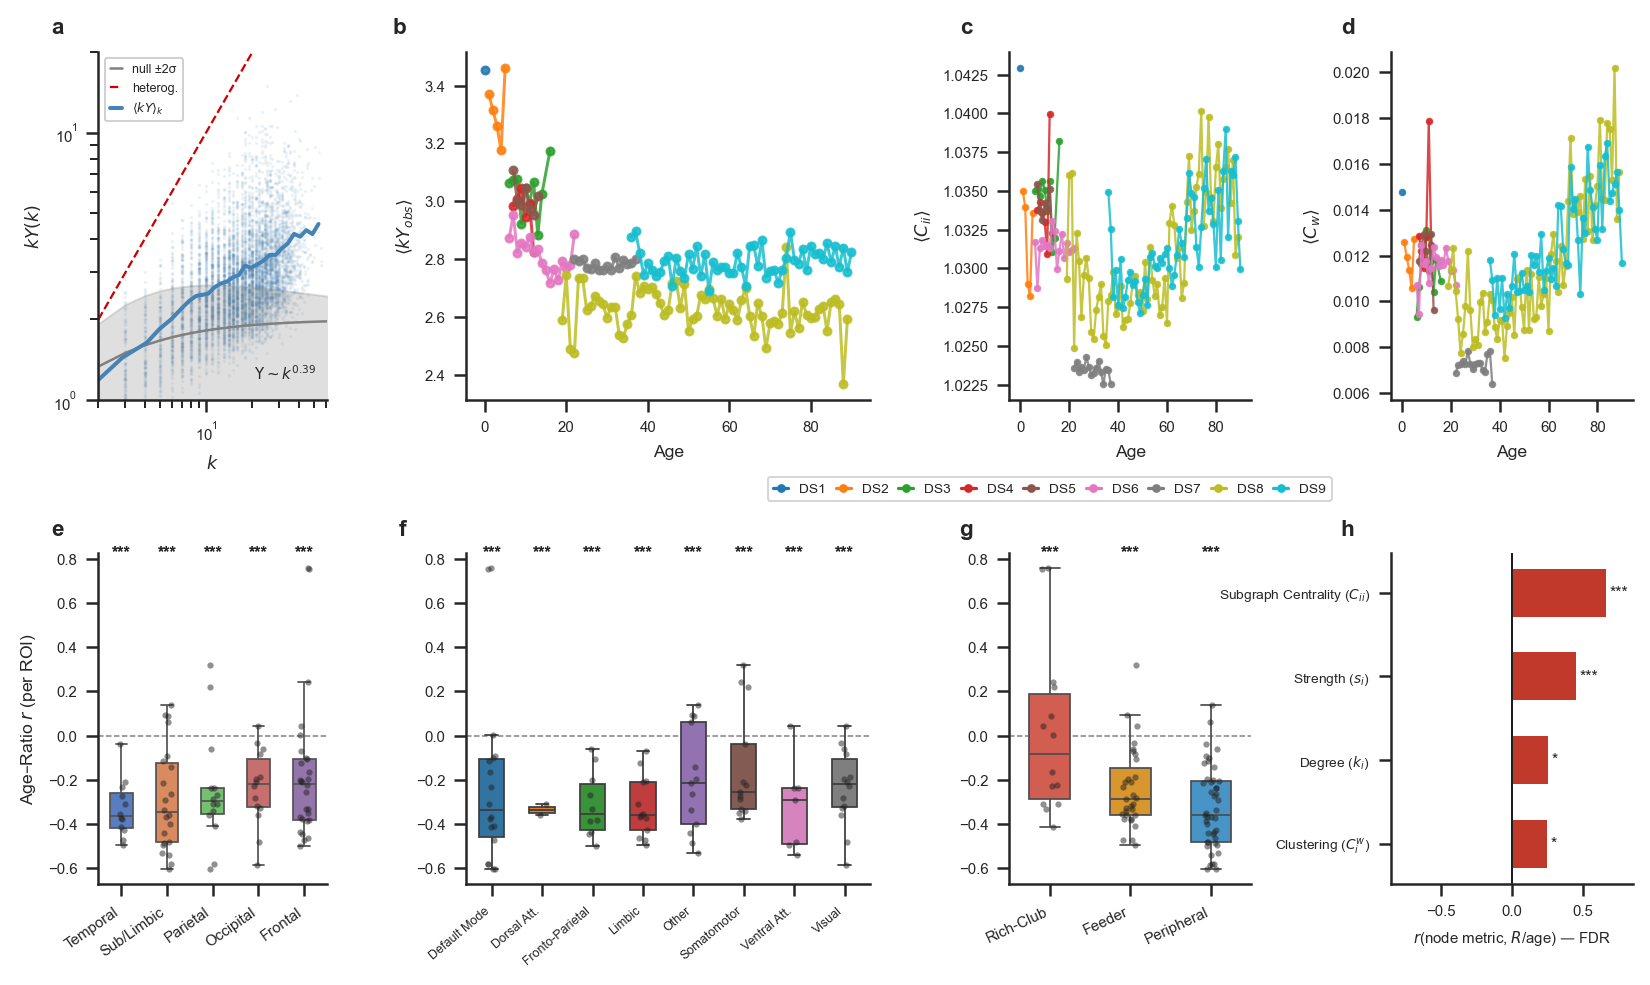

In [ ]:



# ══════════════════════════════════════════════════════════════════════
# FIGURA PRINCIPAL — desarrollo
# ══════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(11, 6))
gs  = gridspec.GridSpec(
    2, 4, figure=fig,
    height_ratios=[1.05, 1],
    width_ratios=[0.85, 1.5, 0.9, 0.9],
    hspace=0.45,   # ← igual que left_gs de fig1
    wspace=0.50,   # ← igual que wspace de fig1
)
ax_kY    = fig.add_subplot(gs[0, 0])
ax_tdis  = fig.add_subplot(gs[0, 1])
ax_tcomm = fig.add_subplot(gs[0, 2])
ax_tclus = fig.add_subplot(gs[0, 3])
bot_axes = [fig.add_subplot(gs[1, i]) for i in range(4)]

# kY scatter
rng_sc = np.random.default_rng(0)
idx_sc = rng_sc.choice(len(k_arr_sc), min(7000,len(k_arr_sc)), replace=False)
ax_kY.scatter(k_arr_sc[idx_sc], kY_arr_sc[idx_sc],
              s=0.4, alpha=0.07, color='steelblue', rasterized=True, zorder=1)
ax_kY.fill_between(NUL['ks'], NUL['kY_lo'], NUL['kY_hi'],
                   color='grey', alpha=0.25, zorder=2)
from scipy.stats import linregress
lr = linregress(np.log10(ks_obs_sc), np.log10(kY_obs_mu_sc))
ax_kY.text(0.95, 0.05, rf'$\Upsilon\sim k^{{{lr.slope:.2f}}}$',
           transform=ax_kY.transAxes, ha='right', va='bottom', fontsize=6)

ax_kY.plot(NUL['ks'], NUL['kY_null'], '-',  color='grey',    lw=1,   label='null ±2σ')
ax_kY.plot(NUL['ks'], NUL['kY_het'],  '--', color='#cc0000', lw=0.9, label='heterog.')
ax_kY.plot(ks_obs_sc, kY_obs_mu_sc,   '-',  color='steelblue', lw=1.6,
           label=r'$\langle kY\rangle_k$')
ax_kY.set_xscale('log'); ax_kY.set_yscale('log')
ax_kY.set_xlim(2, 61);   ax_kY.set_ylim(1, 20)
ax_kY.set_xlabel('$k$'); ax_kY.set_ylabel(r'$kY(k)$')
ax_kY.legend(fontsize=5, handlelength=1, loc='upper left', frameon=True, framealpha=0.9)
sns.despine(ax=ax_kY)

# Trayectorias
traj_cfg = [
    (ax_tdis,  'kY_obs',    r'$\langle kY_{obs}\rangle$', 1.2, 3),
    (ax_tcomm, 'sc_mean', r'$\langle C_{ii}\rangle$',   0.9, 2),
    (ax_tclus, 'C_w',       r'$\langle C_w\rangle$',      0.9, 2),
]
for ax, metric, ylabel, lw, ms in traj_cfg:
    for ds in ds_list:
        sub = data[data.dataset==ds].sort_values('age')
        if metric not in sub.columns or len(sub)==0: continue
        g = sub.groupby('age')[metric].mean()
        ax.plot(g.index, g.values, 'o-', ms=ms, lw=lw, color=ds2col[ds], alpha=0.85)
    ax.set_ylabel(ylabel); ax.set_xlabel('Age')
    sns.despine(ax=ax)

# Leyenda alineada bajo trayectorias
fig.canvas.draw()
p_l = ax_tdis.get_position(); p_r = ax_tclus.get_position()
handles = [plt.Line2D([0],[0], color=ds2col[ds], lw=1.3, marker='o',
                       ms=2.5, label=f'DS{ds}') for ds in ds_list]
fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=((p_l.x0+p_r.x1)/2, p_l.y0-0.1),
           bbox_transform=fig.transFigure,
           ncol=len(ds_list), fontsize=5.5, frameon=True,
           handlelength=1.1, columnspacing=0.7)

draw_bottom_row(bot_axes, df_dev, hr_dev)
for ax, lab in zip([ax_kY, ax_tdis, ax_tcomm, ax_tclus, *bot_axes], 'abcdefgh'):
    ax.text(-0.15, 1.1, lab, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top', ha='right')

plt.savefig('borradorv2/fig2_main.pdf', bbox_inches='tight', dpi=300)
plt.show()


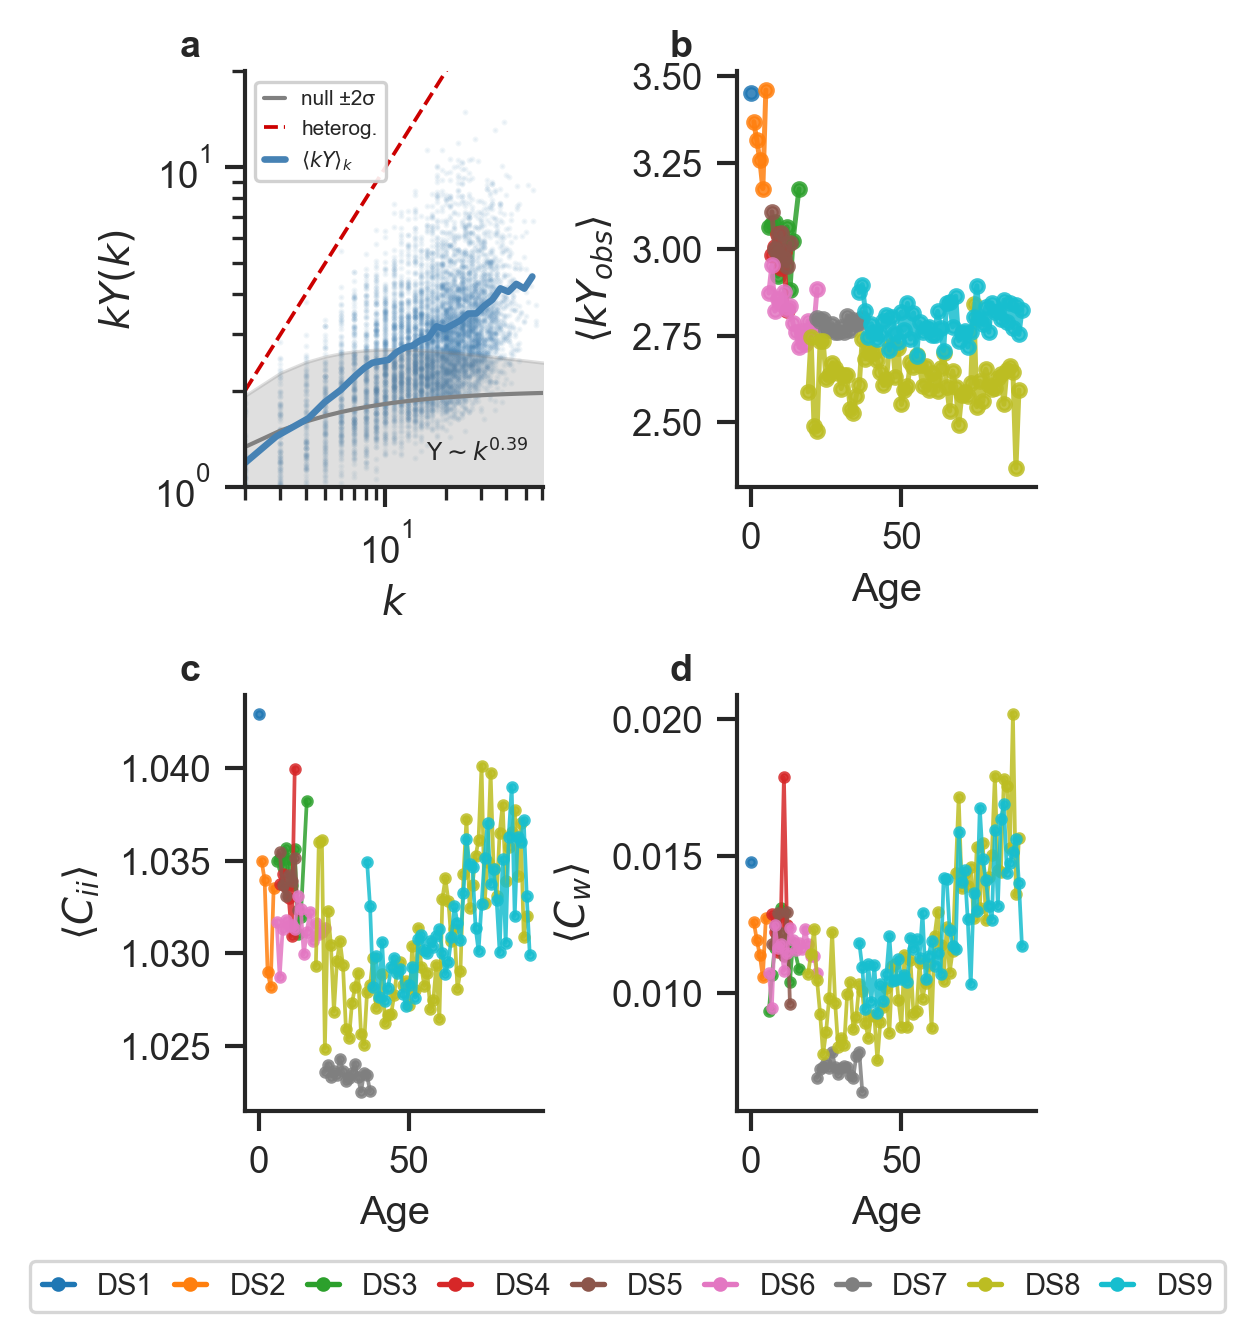

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# =============================================================================
# FIGURE 1: 2x2 Grid (Scatter + Trajectories)
# =============================================================================
fig1 = plt.figure(figsize=(3.4,4.5))
gs1 = gridspec.GridSpec(2, 2, figure=fig1,wspace=0.65, hspace=0.5)

ax_kY    = fig1.add_subplot(gs1[0, 0])
ax_tdis  = fig1.add_subplot(gs1[0, 1])
ax_tcomm = fig1.add_subplot(gs1[1, 0])
ax_tclus = fig1.add_subplot(gs1[1, 1])

# --- Panel (a): kY scatter ---
rng_sc = np.random.default_rng(0)
idx_sc = rng_sc.choice(len(k_arr_sc), min(7000, len(k_arr_sc)), replace=False)

ax_kY.scatter(k_arr_sc[idx_sc], kY_arr_sc[idx_sc],
              s=0.4, alpha=0.07, color='steelblue', rasterized=True, zorder=1)
ax_kY.fill_between(NUL['ks'], NUL['kY_lo'], NUL['kY_hi'],
                   color='grey', alpha=0.25, zorder=2)

lr = linregress(np.log10(ks_obs_sc), np.log10(kY_obs_mu_sc))
ax_kY.text(0.95, 0.05, rf'$\Upsilon\sim k^{{{lr.slope:.2f}}}$',
           transform=ax_kY.transAxes, ha='right', va='bottom', fontsize=6)

ax_kY.plot(NUL['ks'], NUL['kY_null'], '-',  color='grey',    lw=1,   label='null ±2σ')
ax_kY.plot(NUL['ks'], NUL['kY_het'],  '--', color='#cc0000', lw=0.9, label='heterog.')
ax_kY.plot(ks_obs_sc, kY_obs_mu_sc,   '-',  color='steelblue', lw=1.6, label=r'$\langle kY\rangle_k$')

ax_kY.set_xscale('log'); ax_kY.set_yscale('log')
ax_kY.set_xlim(2, 61);   ax_kY.set_ylim(1, 20)
ax_kY.set_xlabel('$k$'); ax_kY.set_ylabel(r'$kY(k)$')
ax_kY.legend(fontsize=5, handlelength=1, loc='upper left', frameon=True, framealpha=0.9)
sns.despine(ax=ax_kY)

# --- Panels (b, c, d): Trajectories ---
traj_cfg = [
    (ax_tdis,  'kY_obs',  r'$\langle kY\rangle$', 1.2, 3),
    (ax_tcomm, 'sc_mean', r'$\langle C_{ii}\rangle$',  0.9, 2),
    (ax_tclus, 'C_w',       r'$\langle C_w\rangle$',      0.9, 2),
]

for ax, metric, ylabel, lw, ms in traj_cfg:
    for ds in ds_list:
        sub = data[data.dataset==ds].sort_values('age')
        if metric not in sub.columns or len(sub)==0: continue
        g = sub.groupby('age')[metric].mean()
        ax.plot(g.index, g.values, 'o-', ms=ms, lw=lw, color=ds2col[ds], alpha=0.85)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Age')
    sns.despine(ax=ax)

# Legend for Trajectories
handles = [plt.Line2D([0],[0], color=ds2col[ds], lw=1.3, marker='o',
                      ms=2.5, label=f'DS{ds}') for ds in ds_list]
fig1.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.05),
            ncol=len(ds_list), fontsize=7, frameon=True, handlelength=1.1, columnspacing=0.7)

for ax, lab in zip([ax_kY, ax_tdis, ax_tcomm, ax_tclus], 'abcd'):
    ax.text(-0.15, 1.1, lab, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top', ha='right')

fig1.savefig('borradorv2/fig2_grid.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:


# =============================================================================
# FIGURE 2: 3x1 Boxplots 
# =============================================================================
fig2, axes2 = plt.subplots(3, 1, figsize=(3.4, 4.5), gridspec_kw={'hspace': 0.8})

for ax, col, order, pal in [
    (axes2[0], 'Lobe', LOBE_ORDER, LOBE_PAL),
    (axes2[1], 'Yeo7', YEO_ORDER,  YEO_PAL),
    (axes2[2], 'Club', CLUB_ORDER, CLUB_PAL)
]:
    sns.boxplot(data=df_dev, x=col, y='r', order=order,
                palette=pal, hue=col, legend=False, ax=ax, **BOX_KW)
    sns.stripplot(data=df_dev, x=col, y='r', order=order,
                  ax=ax, **STRIP_KW)
    
    ax.axhline(0, ls='--', lw=0.6, color='grey', zorder=1)
    ax.set_xlabel('')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=35, ha='right', fontsize=6)
    add_stars(ax, df_dev, col, order)
    sns.despine(ax=ax)

axes2[0].set_ylabel(r'Age–Ratio $r$')
axes2[1].set_ylabel(r'Age–Ratio $r$')
axes2[2].set_ylabel(r'Age–Ratio $r$')

# Synchronize ylim
ymin = min(a.get_ylim()[0] for a in axes2)
ymax = max(a.get_ylim()[1] for a in axes2)
for a in axes2: 
    a.set_ylim(ymin, ymax)

# Re-apply stars with synced limits
for ax, col, order in zip(axes2, ['Lobe', 'Yeo7', 'Club'], [LOBE_ORDER, YEO_ORDER, CLUB_ORDER]):
    add_stars(ax, df_dev, col, order)

fig2.savefig('borradorv2/fig2_boxplots.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [36]:

# =============================================================================
# LATEX TABLE: Metric Correlation
# =============================================================================
hr_dev_table = hr_dev[['label', 'r', 'p_fdr']].copy()
hr_dev_table.columns = ['Node Metric', '$r$', '$p_{FDR}$']

latex_table = hr_dev_table.to_latex(
    index=False,
    float_format="%.3f",
    escape=False,
    column_format="lccc"
)

print(latex_table)

\begin{tabular}{lccc}
\toprule
Node Metric & $r$ & $p_{FDR}$ \\
\midrule
Clustering ($C^w_i$) & 0.249 & 0.018 \\
Degree ($k_i$) & 0.256 & 0.018 \\
Strength ($s_i$) & 0.444 & 0.000 \\
Subgraph Centrality ($C_{ii}$) & 0.666 & 0.000 \\
\bottomrule
\end{tabular}



# Supplementary

# Fig Supp. 3. Aging disparity-node age rel

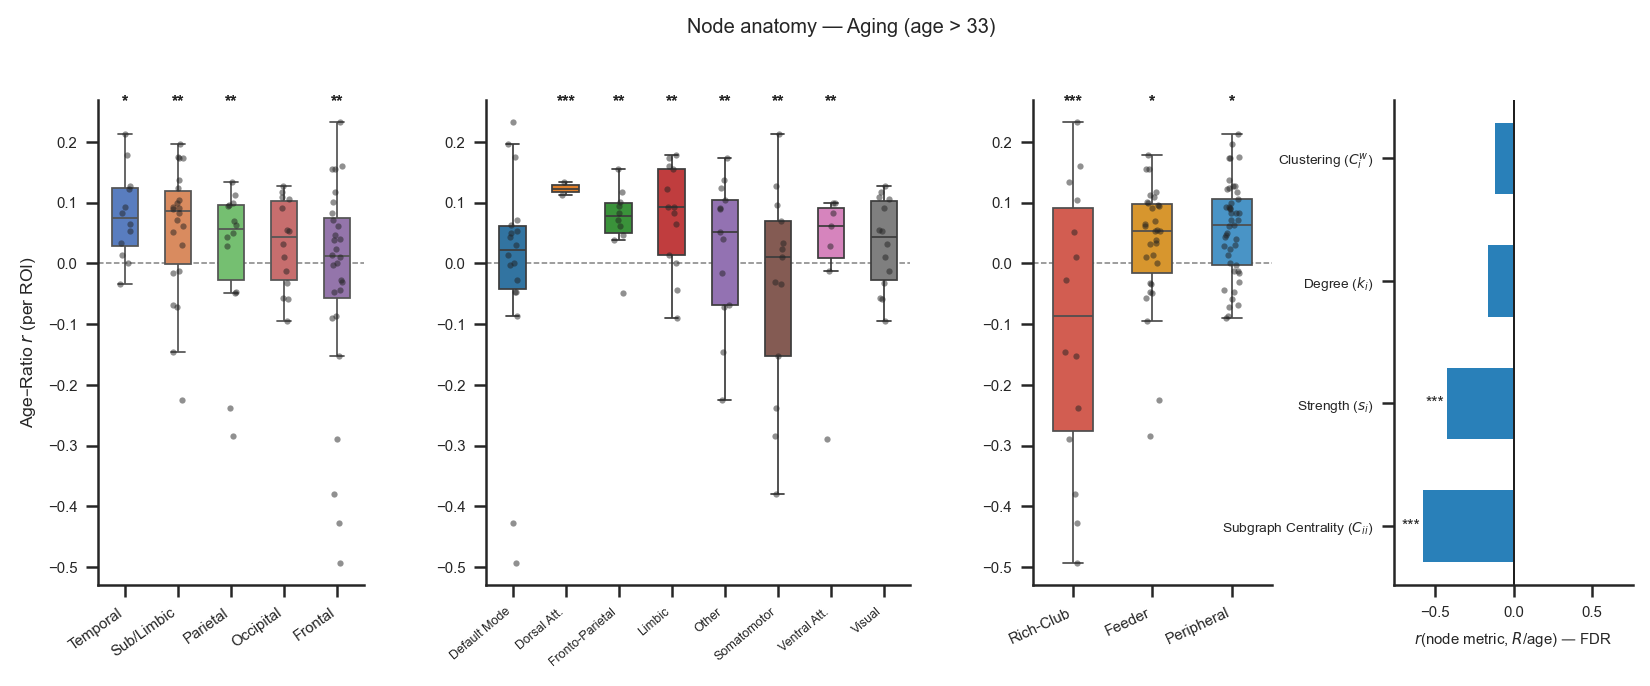

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# FIGURA SUPLEMENTARIA — aging
# ══════════════════════════════════════════════════════════════════════
fig_s, axes_s = plt.subplots(1, 4, figsize=(11, 3.5),
                              gridspec_kw={'width_ratios':[1,1.6,0.9,0.9],
                                           'wspace':0.42})
fig_s.suptitle(f'Node anatomy — Aging (age > {AGE_SPLIT})',
               fontsize=8, y=1.01)
draw_bottom_row(list(axes_s), df_age, hr_age)

plt.savefig('borradorv2/fig2_supp_aging.pdf', bbox_inches='tight', dpi=300)
plt.show()